# CLUSTERING ANALYSIS 

Understanding and Implementing K-Means, Hierarchical, and DBSCAN Algorithms

In [2]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
df = pd.read_excel("C:\\Users\\DELL\\Desktop\\DATA SCIENCE ASSIGNMENT\\Clustering\\EastWestAirlines.xlsx", sheet_name="data")
df

,ID#,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?
0,1,28143,0,1,1,1,174,1,0,0,7000,0
1,2,19244,0,1,1,1,215,2,0,0,6968,0
2,3,41354,0,1,1,1,4123,4,0,0,7034,0
3,4,14776,0,1,1,1,500,1,0,0,6952,0
4,5,97752,0,4,1,1,43300,26,2077,4,6935,1
...,...,...,...,...,...,...,...,...,...,...,...,...
3994,4017,18476,0,1,1,1,8525,4,200,1,1403,1
3995,4018,64385,0,1,1,1,981,5,0,0,1395,1
3996,4019,73597,0,3,1,1,25447,8,0,0,1402,1
3997,4020,54899,0,1,1,1,500,1,500,1,1401,0


In [4]:
df = df.drop("ID#", axis=1)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3999 entries, 0 to 3998
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   Balance            3999 non-null   int64
 1   Qual_miles         3999 non-null   int64
 2   cc1_miles          3999 non-null   int64
 3   cc2_miles          3999 non-null   int64
 4   cc3_miles          3999 non-null   int64
 5   Bonus_miles        3999 non-null   int64
 6   Bonus_trans        3999 non-null   int64
 7   Flight_miles_12mo  3999 non-null   int64
 8   Flight_trans_12    3999 non-null   int64
 9   Days_since_enroll  3999 non-null   int64
 10  Award?             3999 non-null   int64
dtypes: int64(11)
memory usage: 343.8 KB


In [6]:
df.isnull().sum()

Balance              0
Qual_miles           0
cc1_miles            0
cc2_miles            0
cc3_miles            0
Bonus_miles          0
Bonus_trans          0
Flight_miles_12mo    0
Flight_trans_12      0
Days_since_enroll    0
Award?               0
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(1)

<Axes: >

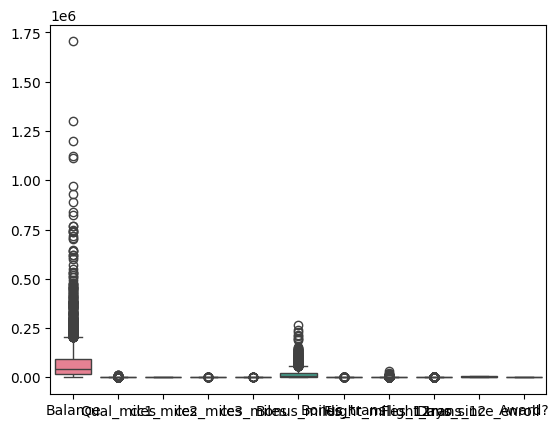

In [8]:
import seaborn as sns

sns.boxplot(data=df)

In [9]:
outlier_counts = {}

for col in df.columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower) | (df[col] > upper)]
    outlier_counts[col] = outliers.shape[0]

print(outlier_counts)

{'Balance': 266, 'Qual_miles': 226, 'cc1_miles': 0, 'cc2_miles': 43, 'cc3_miles': 18, 'Bonus_miles': 280, 'Bonus_trans': 63, 'Flight_miles_12mo': 569, 'Flight_trans_12': 565, 'Days_since_enroll': 0, 'Award?': 0}


Outliers were retained in the dataset because they may represent important customer segments such as high-value or frequent flyers. Removing them could lead to loss of valuable information. Additionally, algorithms like DBSCAN can handle outliers effectively by identifying them as noise, making it unnecessary to remove them beforehand.

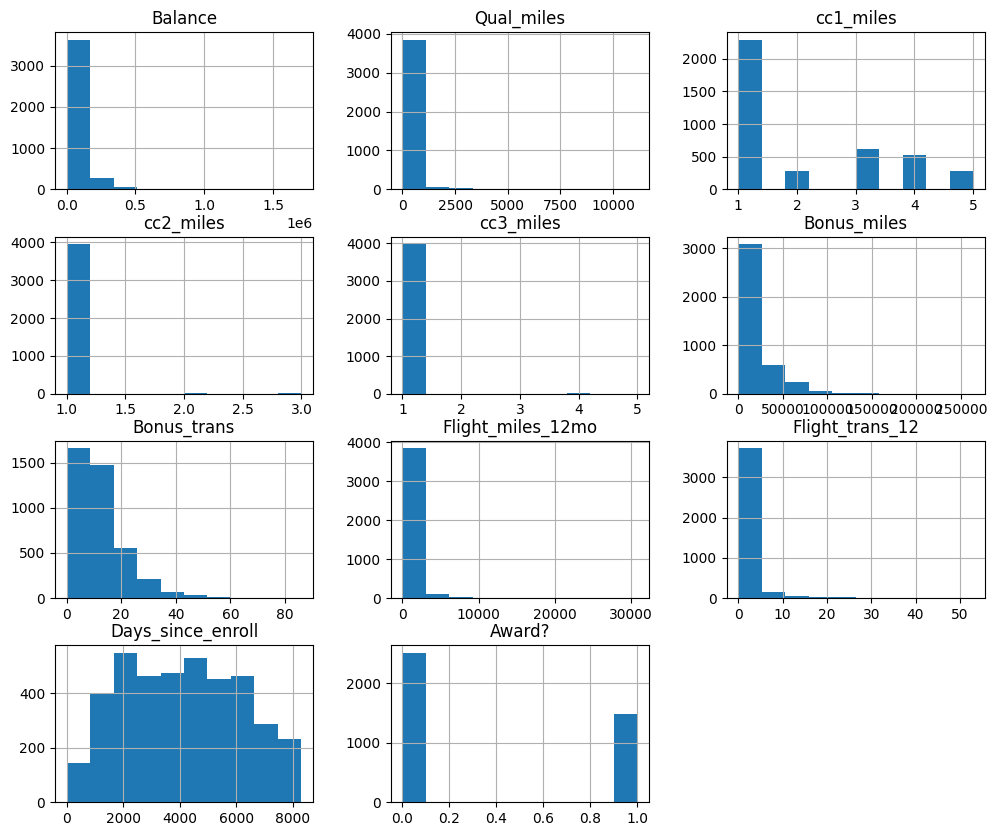

<Axes: >

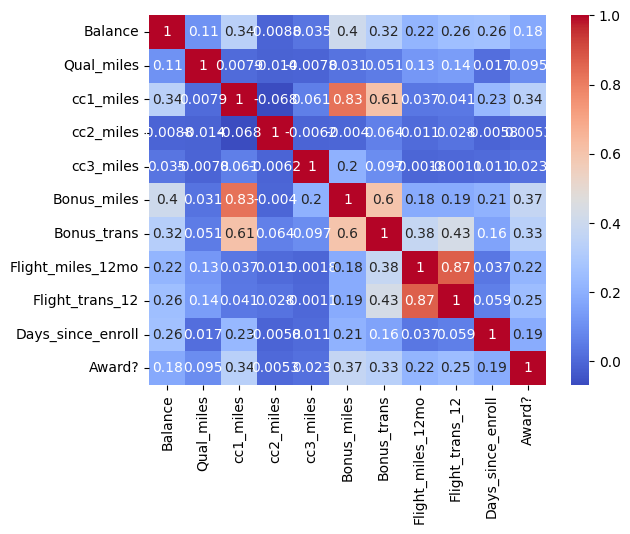

In [10]:
import matplotlib.pyplot as plt

df.hist(figsize=(12,10))
plt.show()

# Correlation heatmap
import seaborn as sns
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")

In [11]:
from sklearn.preprocessing import StandardScaler

sc = StandardScaler()
X_sc = sc.fit_transform(df)
X_sc = pd.DataFrame(X_sc, columns=df.columns)
X_sc

,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?
0,-0.451141,-0.186299,-0.769578,-0.098242,-0.062767,-0.702786,-1.104065,-0.328603,-0.362168,1.395454,-0.766919
1,-0.539457,-0.186299,-0.769578,-0.098242,-0.062767,-0.701088,-0.999926,-0.328603,-0.362168,1.379957,-0.766919
2,-0.320031,-0.186299,-0.769578,-0.098242,-0.062767,-0.539253,-0.791649,-0.328603,-0.362168,1.411920,-0.766919
3,-0.583799,-0.186299,-0.769578,-0.098242,-0.062767,-0.689286,-1.104065,-0.328603,-0.362168,1.372208,-0.766919
4,0.239678,-0.186299,1.409471,-0.098242,-0.062767,1.083121,1.499394,1.154932,0.692490,1.363975,1.303918
...,...,...,...,...,...,...,...,...,...,...,...
3994,-0.547079,-0.186299,-0.769578,-0.098242,-0.062767,-0.356960,-0.791649,-0.185750,-0.098503,-1.315120,1.303918
3995,-0.091465,-0.186299,-0.769578,-0.098242,-0.062767,-0.669367,-0.687511,-0.328603,-0.362168,-1.318994,1.303918
3996,-0.000043,-0.186299,0.683121,-0.098242,-0.062767,0.343804,-0.375096,-0.328603,-0.362168,-1.315604,1.303918
3997,-0.185607,-0.186299,-0.769578,-0.098242,-0.062767,-0.689286,-1.104065,0.028531,-0.098503,-1.316088,-0.766919


##  K-Means Clustering

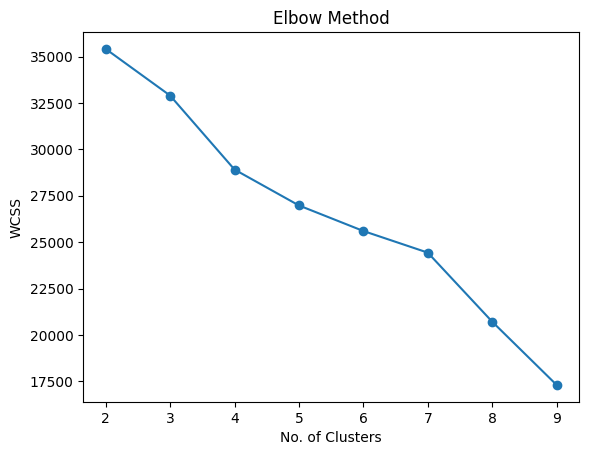

In [12]:
from sklearn.cluster import KMeans

wcss = []
for i in range(2,10):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X_sc)
    wcss.append(kmeans.inertia_)

plt.plot(range(2,10), wcss, marker='o')
plt.title("Elbow Method")
plt.xlabel("No. of Clusters")
plt.ylabel("WCSS")
plt.show()

In [13]:
kmeans = KMeans(n_clusters=2, random_state=42)
kmeans_labels = kmeans.fit_predict(X_sc)

df["KMeans_Cluster"] = kmeans_labels

In [14]:
from sklearn.metrics import silhouette_score

print("KMeans Score:", silhouette_score(X_sc, kmeans_labels))

KMeans Score: 0.32542136327826215


In [15]:
from sklearn.metrics import silhouette_score

for k in range(2, 10):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_sc)
    score = silhouette_score(X_sc, labels)
    print(f"K = {k}, Score = {score}")

K = 2, Score = 0.32542136327826215
K = 3, Score = 0.2674062376813128
K = 4, Score = 0.19071186813310886
K = 5, Score = 0.2005393837499611
K = 6, Score = 0.21101381221427787
K = 7, Score = 0.22192199091290543
K = 8, Score = 0.2307025196109592
K = 9, Score = 0.24235773377377628


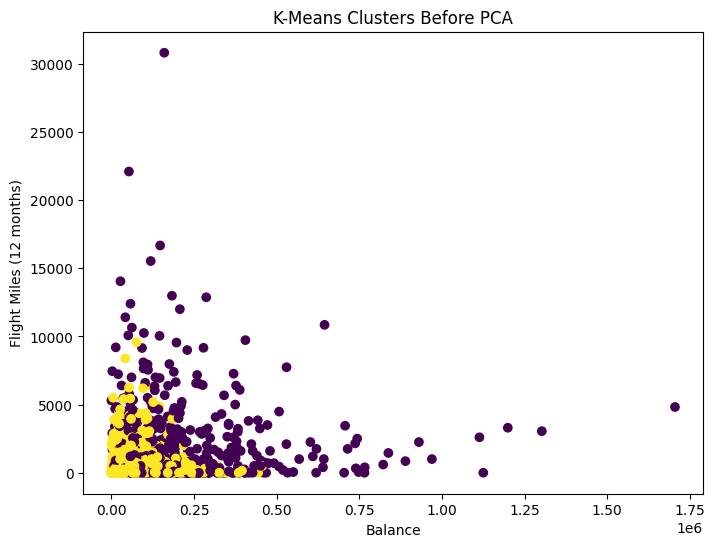

In [16]:
plt.figure(figsize=(8,6))

plt.scatter(
    df["Balance"], 
    df["Flight_miles_12mo"], 
    c=kmeans_labels
)

plt.xlabel("Balance")
plt.ylabel("Flight Miles (12 months)")
plt.title("K-Means Clusters Before PCA")

plt.show()

Using K=2, the clustering results divide customers into two broad segments. One cluster represents high-value customers with higher balance and frequent flying activity, indicating strong loyalty and engagement. The second cluster consists of low-value customers with lower balance and limited flight activity, representing occasional or inactive users. However, this segmentation is relatively general and does not capture more detailed behavioral differences among customers.

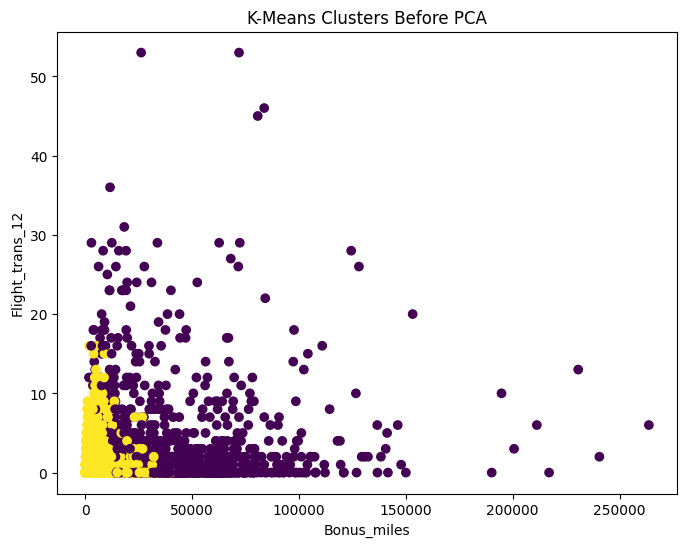

In [17]:
plt.figure(figsize=(8,6))

plt.scatter(
    df["Bonus_miles"], 
    df["Flight_trans_12"], 
    c=kmeans_labels
)

plt.xlabel("Bonus_miles")
plt.ylabel("Flight_trans_12")
plt.title("K-Means Clusters Before PCA")

plt.show()

The scatter plot between bonus miles and flight transactions shows clearer separation between clusters compared to the previous visualization. One cluster (yellow) represents customers with low flight activity and minimal use of reward programs, indicating low engagement. The other cluster (purple) consists of customers with higher flight transactions and bonus miles, representing active and loyal customers. A slight overlap between clusters suggests the presence of customers with mixed behavior patterns.

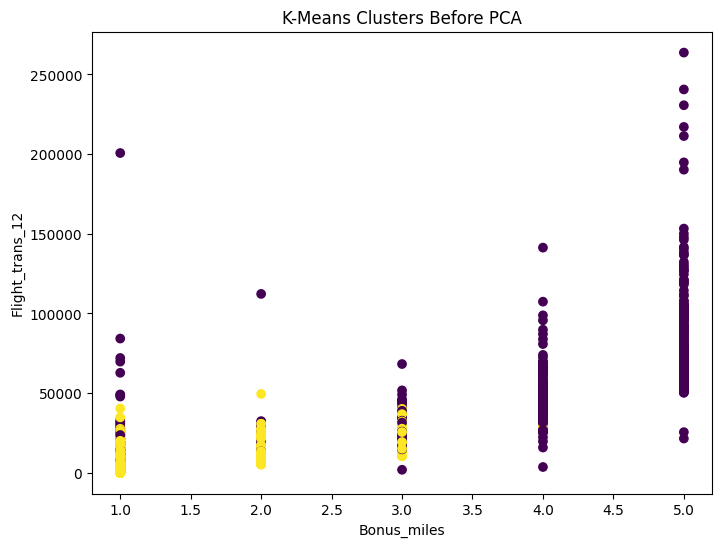

In [18]:
plt.figure(figsize=(8,6))

plt.scatter(
    df["cc1_miles"], 
    df["Bonus_miles"], 
    c=kmeans_labels
)

plt.xlabel("Bonus_miles")
plt.ylabel("Flight_trans_12")
plt.title("K-Means Clusters Before PCA")

plt.show()

The scatter plot between cc1_miles and bonus_miles shows vertical clustering due to the discrete nature of the credit card usage variable, which takes values from 1 to 5. Each vertical line represents a category of credit card spending. Customers with higher cc1_miles values tend to have higher bonus miles, indicating that increased credit card usage is associated with greater reward accumulation. This suggests that credit card activity plays a significant role in customer engagement and reward earning behavior.

## Kmeans with PCA

In [19]:
from sklearn.decomposition import PCA

pca = PCA(n_components=5)
X_pca = pca.fit_transform(X_sc)

In [21]:
kmeans = KMeans(n_clusters=5, random_state=42)
kmeans_labelsp = kmeans.fit_predict(X_pca)

df["KMeans_Cluster"] = kmeans_labelsp

from sklearn.metrics import silhouette_score

print("KMeans Score with PCA:", silhouette_score(X_pca, kmeans_labelsp))

KMeans Score with PCA: 0.4658524622327929


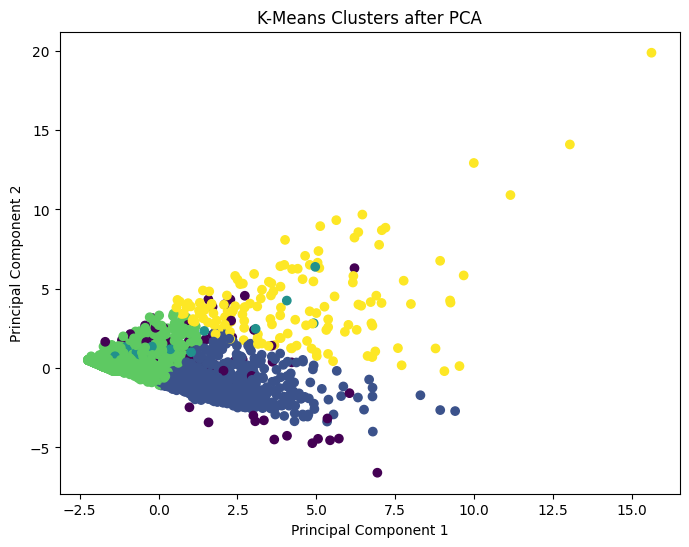

In [23]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0], X_pca[:,1], c=kmeans_labelsp)
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("K-Means Clusters after PCA")
plt.show()

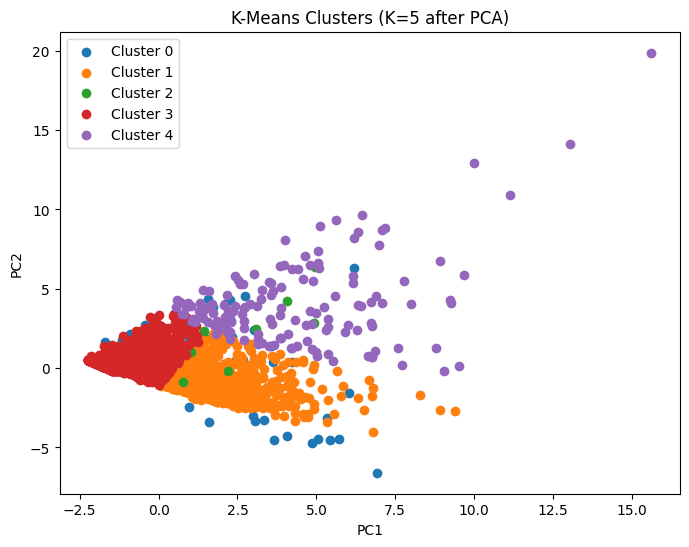

In [25]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

for i in range(5):
    plt.scatter(
        X_pca[kmeans_labelsp == i, 0],
        X_pca[kmeans_labelsp == i, 1],
        label=f"Cluster {i}"
    )

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("K-Means Clusters (K=5 after PCA)")
plt.legend()
plt.show()

After applying Principal Component Analysis (PCA) and performing K-Means clustering with K=5, the clusters appear more clearly separated compared to the original feature space. PCA helped in reducing dimensionality and removing noise, which improved the overall structure of the data and enhanced cluster formation.

However, a slight overlap between some clusters is still observed. This overlap indicates that certain customers exhibit mixed behavior patterns, such as moderate travel activity combined with varying levels of reward usage or credit card spending. Such overlap is expected in real-world datasets where customer characteristics are not strictly distinct.

Overall, the clustering results demonstrate improved separation with meaningful segmentation, while the minor overlap reflects the natural complexity and variability in customer behavior.

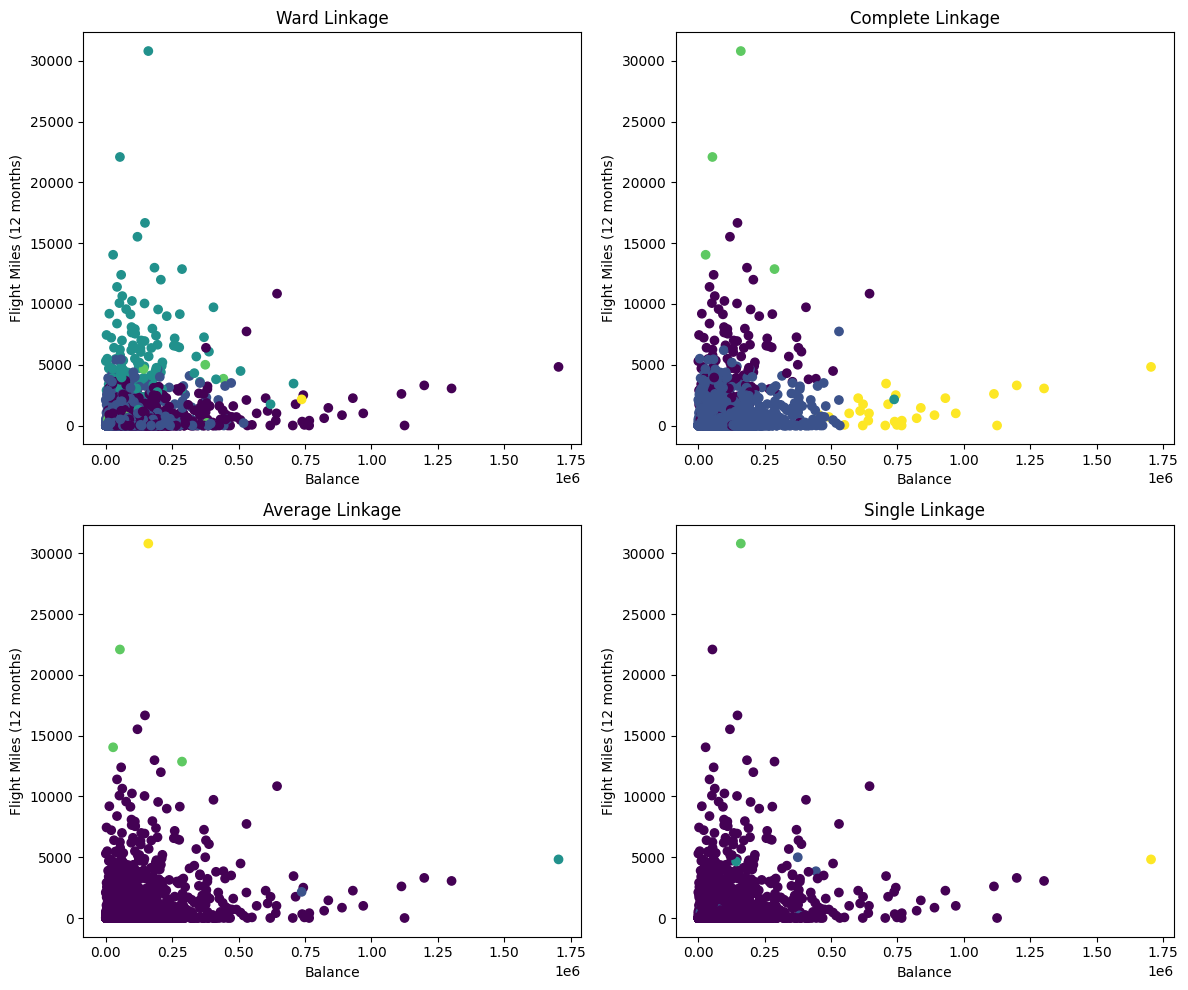

In [27]:
import matplotlib.pyplot as plt
from sklearn.cluster import AgglomerativeClustering

linkages = ["ward", "complete", "average", "single"]

plt.figure(figsize=(12,10))

for i, link in enumerate(linkages):
    
    hc = AgglomerativeClustering(n_clusters=5, linkage=link)
    labels = hc.fit_predict(X_sc)
    
    plt.subplot(2, 2, i+1)
    plt.scatter(
        df["Balance"], 
        df["Flight_miles_12mo"], 
        c=labels
    )
    
    plt.title(f"{link.capitalize()} Linkage")
    plt.xlabel("Balance")
    plt.ylabel("Flight Miles (12 months)")

plt.tight_layout()
plt.show()

Although average linkage produced the highest silhouette score, the visualization revealed that most data points were grouped into a single dominant cluster, while the remaining clusters contained very few points. This indicates highly imbalanced clustering and poor segmentation. Therefore, despite the high silhouette score, average linkage is not considered suitable for this dataset.


The clustering results using complete linkage show improved separation compared to other methods. One cluster (yellow) is clearly separated, representing high-value customers with higher activity levels. However, the blue and purple clusters show some overlap near lower values, indicating customers with similar low to moderate engagement levels. This overlap reflects the gradual transition in customer behavior. Overall, complete linkage provides a balanced and meaningful segmentation despite minor overlaps.

## DBSCAN

In [28]:
from sklearn.cluster import DBSCAN
dbscan = DBSCAN(eps=1.5, min_samples=5)
labels_db = dbscan.fit_predict(X_sc)

print("Unique labels:", set(labels_db))  # -1 means outliers

Unique labels: {np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(-1)}


In [29]:
n_clusters = len(set(labels_db)) - (1 if -1 in labels_db else 0)
n_noise = list(labels_db).count(-1)

print("Number of clusters:", n_clusters)
print("Number of noise points:", n_noise)

Number of clusters: 5
Number of noise points: 310


In [30]:
if n_clusters > 1:
    score3 = silhouette_score(X_sc, labels_db)
    print("DBSCAN Silhouette Score:", score3)
else:
    print("Silhouette Score cannot be calculated")

DBSCAN Silhouette Score: 0.253747538041624


In [31]:
eps_values = [0.5, 1.0, 1.5, 2.0]
min_samples_values = [3, 5, 10]

for eps in eps_values:
    for ms in min_samples_values:
        
        db = DBSCAN(eps=eps, min_samples=ms)
        labels = db.fit_predict(X_sc)
        
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        
        if n_clusters > 1:
            score4 = silhouette_score(X_sc, labels)
            print(f"eps={eps}, min_samples={ms} → clusters={n_clusters}, score={score4}")
        else:
            print(f"eps={eps}, min_samples={ms} → clusters={n_clusters} (not valid)")

eps=0.5, min_samples=3 → clusters=40, score=-0.11448578186172835
eps=0.5, min_samples=5 → clusters=16, score=-0.07834757831741163
eps=0.5, min_samples=10 → clusters=9, score=-0.0983562695924908
eps=1.0, min_samples=3 → clusters=10, score=0.09390508562243595
eps=1.0, min_samples=5 → clusters=6, score=0.19845036227961305
eps=1.0, min_samples=10 → clusters=3, score=0.21846817453796039
eps=1.5, min_samples=3 → clusters=9, score=0.21254627881452187
eps=1.5, min_samples=5 → clusters=5, score=0.253747538041624
eps=1.5, min_samples=10 → clusters=3, score=0.24624177599774275
eps=2.0, min_samples=3 → clusters=12, score=0.2457363433586349
eps=2.0, min_samples=5 → clusters=6, score=0.25376617762145437
eps=2.0, min_samples=10 → clusters=3, score=0.25546923305422986


DBSCAN clustering was performed using different values of epsilon and minimum samples. It was observed that very small epsilon values resulted in too many clusters and poor silhouette scores due to over-segmentation. As epsilon increased, the number of clusters decreased and clustering performance improved. The best result was obtained at eps = 2.0 and min_samples = 10, with a silhouette score of approximately 0.255. However, compared to K-Means and hierarchical clustering, DBSCAN showed lower performance, indicating that the dataset is not well-suited for density-based clustering.

## Conclusion

Clustering analysis was performed on the airline dataset using K-Means, Hierarchical Clustering, and DBSCAN to identify meaningful customer segments based on flying patterns, reward usage, and credit card activity.

K-Means clustering initially provided basic segmentation, but after applying Principal Component Analysis (PCA), the clustering performance improved significantly, resulting in better-defined and more meaningful customer groups. Hierarchical clustering was further explored using different linkage methods, where complete linkage provided balanced and well-separated clusters, especially after applying PCA.

DBSCAN was also implemented to identify density-based clusters and detect outliers. However, it showed comparatively lower performance, as the dataset does not exhibit strong density-based separation and contains overlapping patterns.

Overall, K-Means with PCA and hierarchical clustering with complete linkage were found to be the most effective methods for this dataset. The analysis successfully identified distinct customer segments such as high-value frequent flyers, reward-oriented users, and low-engagement customers. These insights can help the airline design targeted marketing strategies, improve customer retention, and enhance loyalty programs.